# Understanding swizzling

This notebook is written to play with swizzle parameters using the [swizzle method from cutlass](https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py).

## Imports, classes, functions

In [2]:
from typing import Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# The following code taken and modified from https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py.

def shiftr(a, s):
  return a >> s if s > 0 else shiftl(a, -s)


def shiftl(a, s):
  return a << s if s > 0 else shiftr(a, -s)


class Swizzle:
    """Performs swizzling operations given the parameters bits_num, base, and shift.

        Given the following operation example:
            i = i ^ ((i & 111000000) >> 3)

        - i indicates the offset or the index to be transformed
        - 111000000 is the yyy_mask
            - the number of zeroes comes from (base + shift) where
                - base indicates the number of least-significant bits to keep constant
                - shift indicates the distance to shift
            - `111` comes from (1 << bits_num) - 1
        - 3 from `>> 3` is the number to shift
    """
    def __init__(self, bits_num, base, shift):
        assert bits_num >= 0
        assert base >= 0
        assert shift >= 0
        assert abs(shift) >= bits_num
        self.bits_num = bits_num
        self.base = base
        self.shift = shift
        bit_mask = (1 << bits_num) - 1
        self.yyy_mask = bit_mask << (base + max(0,shift))

    # operator ()    (transform integer)
    def __call__(self, offset):
        return offset ^ shiftr(offset & self.yyy_mask, self.shift)

In [17]:
def plot_matrix(
    bank_array: np.ndarray,
    annotate_array: np.ndarray,
    num_rows: int,
    num_cols: int,
    title: str = "",
    hline_iter: int = -1,
    fig_size: tuple = (10, 20),
    save_file: Optional[str] = None,
):
    plt.close()
    
    bank_array     = bank_array.astype(int)
    annotate_array = annotate_array.astype(int)

    _, ax = plt.subplots(figsize=fig_size)
    ax.imshow(bank_array, cmap="Greys")
    ax.set_xticks(np.arange(num_cols)-0.5, minor=True)
    ax.set_yticks(np.arange(num_rows)-0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1.5)

    # Add bank annotations.
    for i in range(bank_array.shape[0]):
        for j in range(bank_array.shape[1]):
            color = "w" if bank_array[i, j] % 32 > 16 else "black"
            ax.text(j, i, annotate_array[i, j], ha="center", va="center", color=color, size="small")

    if hline_iter > 0:
        for row_idx in range(1, num_rows // hline_iter):
            ax.axhline(y=(row_idx * hline_iter) - 0.5, color="orange", linestyle='-', linewidth=2)

    plt.title(title) 
    plt.tight_layout()

    if save_file is not None:
        plt.savefig(save_file, bbox_inches="tight")

    plt.show()

In [6]:
def perform_swizzle(swizzle_op: Swizzle, matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Performs swizzle on matrix; returns the updated bank indices and the updated swizzled"""
    updated_banks = np.zeros(matrix.shape).astype(int)
    swizzled_matrix          = np.zeros(matrix.shape).astype(int)

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            offset         = matrix[row_idx, col_idx]
            updated_offset = swizzle_op(offset)
            new_row_idx    = updated_offset // matrix.shape[1]
            new_col_idx    = updated_offset % matrix.shape[1]
            swizzled_matrix[new_row_idx, new_col_idx] = matrix[row_idx, col_idx]
            updated_banks[row_idx, col_idx] = int((updated_offset % (32 * 4 / element_size)) // (4 / element_size))

    return updated_banks, swizzled_matrix

## Parameters

The parameters are as follows.

| name | description |
| -- | -- |
| M | The number of rows in the matrix |
| N | The number of columns in the matrix |
| element_size | The size of elements in bytes, which determines how many elements assigned consecutively in each bank |
| swizzle_num_mask_bits | The number of swizzle mask bits |
| swizzle_num_base | The number of swizzle base bits |
| swizzle_num_shift | The number of swizzle shift bits |

## Toy example

In [7]:
# Initialize parameters.
M = 32
N = 32
element_size = 4

In [8]:
# Initialize the matrix with indices as its values.
matrix = np.arange(M * N).reshape((M, N))
matrix

array([[   0,    1,    2, ...,   29,   30,   31],
       [  32,   33,   34, ...,   61,   62,   63],
       [  64,   65,   66, ...,   93,   94,   95],
       ...,
       [ 928,  929,  930, ...,  957,  958,  959],
       [ 960,  961,  962, ...,  989,  990,  991],
       [ 992,  993,  994, ..., 1021, 1022, 1023]], shape=(32, 32))

In [9]:
# Divide the matrix into banks.
matrix_by_bank = ((matrix % (32 * 4 / element_size)) // (4 / element_size)).astype(int)
matrix_by_bank

array([[ 0,  1,  2, ..., 29, 30, 31],
       [ 0,  1,  2, ..., 29, 30, 31],
       [ 0,  1,  2, ..., 29, 30, 31],
       ...,
       [ 0,  1,  2, ..., 29, 30, 31],
       [ 0,  1,  2, ..., 29, 30, 31],
       [ 0,  1,  2, ..., 29, 30, 31]], shape=(32, 32))

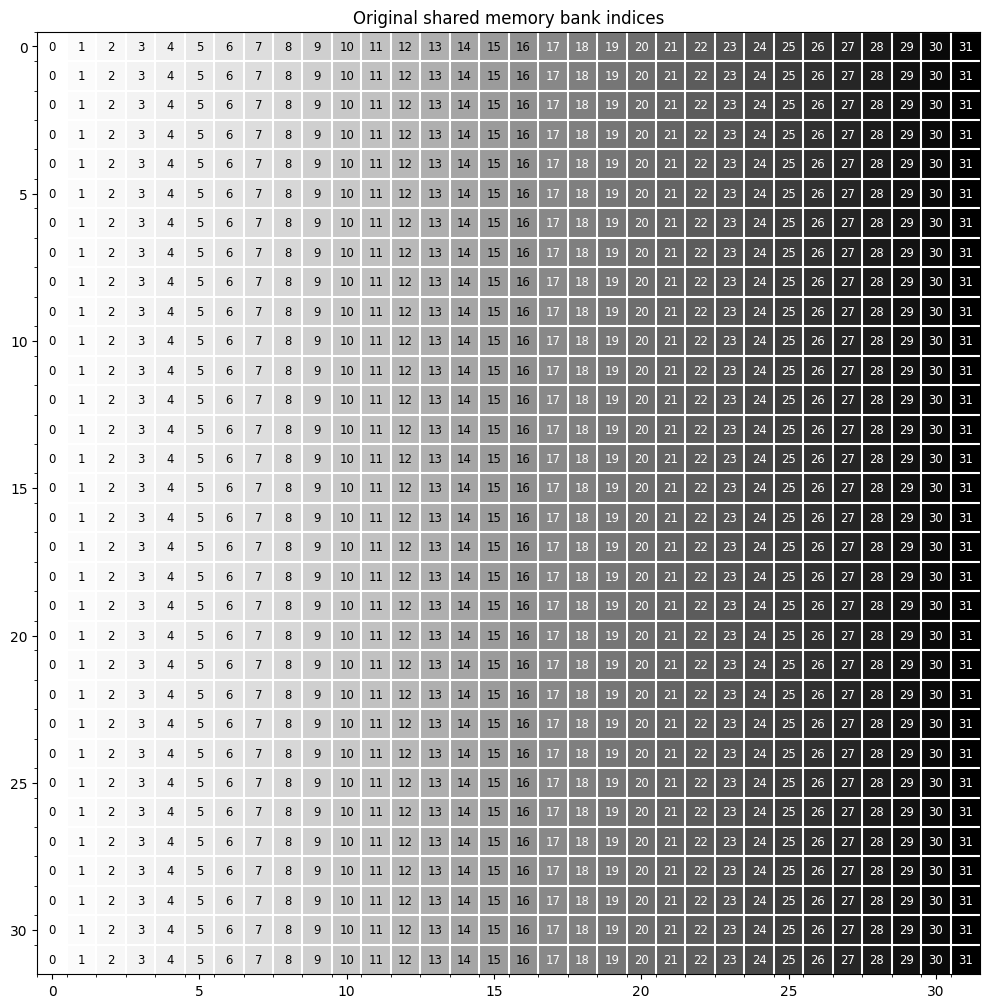

In [10]:
# Visualize the elements in As colored by banks.
plot_matrix(
    matrix_by_bank, matrix_by_bank, M, N, "Original shared memory bank indices", save_file="kernel14_example_before")

In [11]:
# Feel free to play around with the values below.
base     = 0
bits_num = 5 # 32 elements to permute --> log2(32)
# Requirement: abs(shift) >= bits_num
shift    = 5 # Each full-bank "row" contains 32 elements --> log2(32) - 0

# Create the swizzle_op object.
swizzle_op = Swizzle(bits_num, base, shift)
swizzled_matrix_by_banks, swizzled_matrix = perform_swizzle(swizzle_op, matrix)

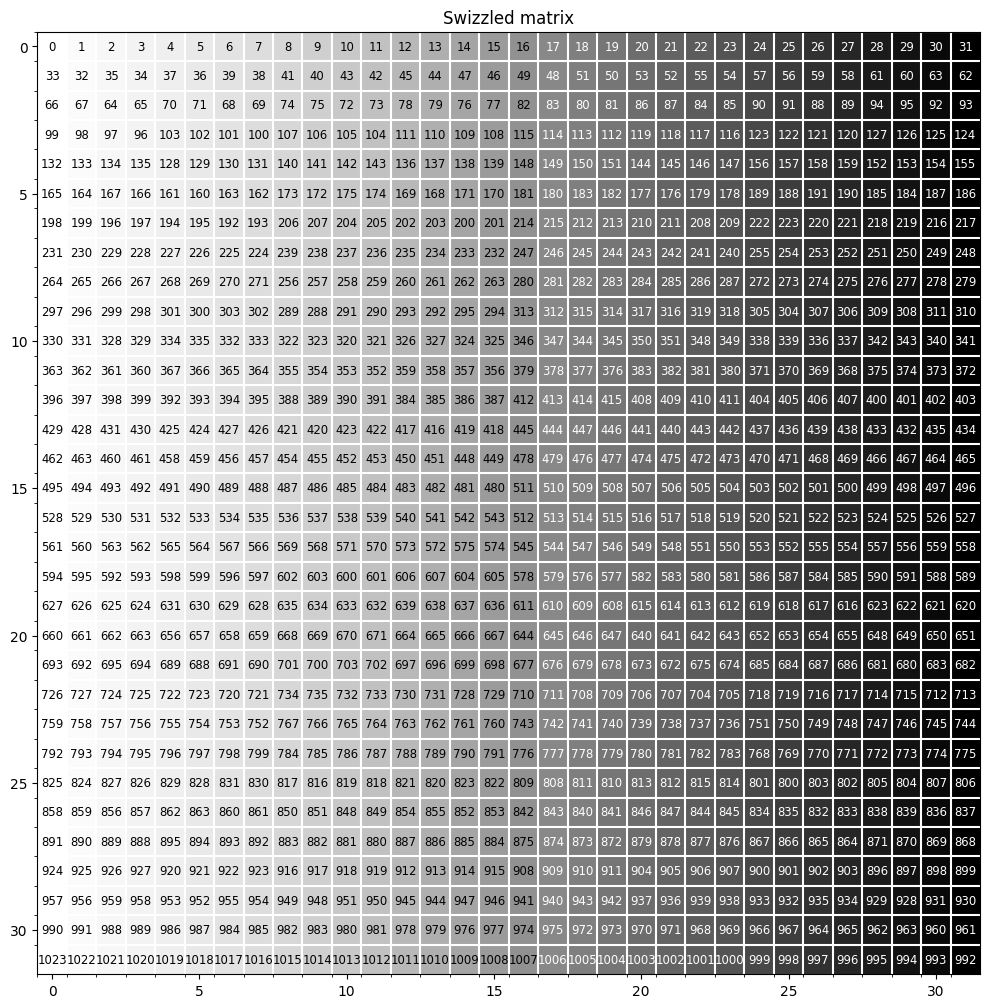

In [12]:
plot_matrix(
    matrix_by_bank, swizzled_matrix, M, N, "Swizzled matrix", -1)

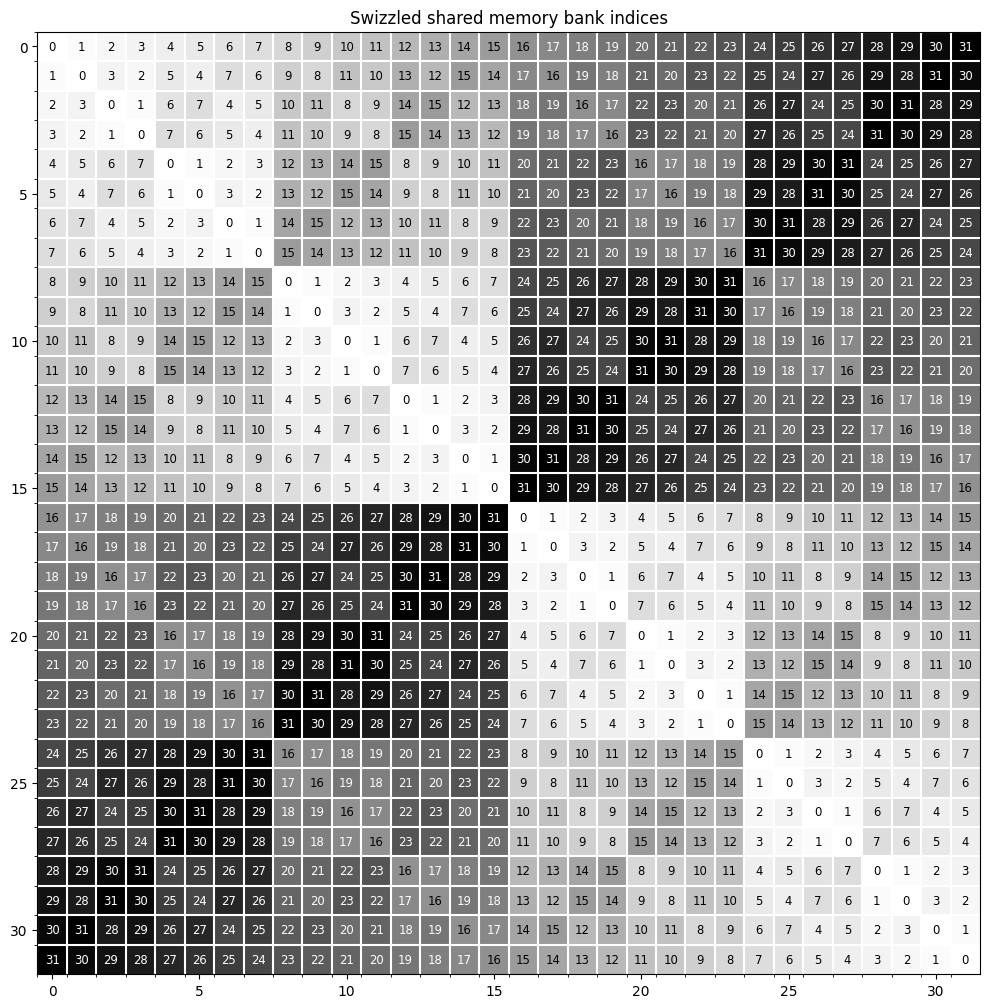

In [13]:
plot_matrix(
    swizzled_matrix_by_banks, swizzled_matrix_by_banks, M, N, "Swizzled shared memory bank indices", -1, save_file="kernel14_example_after")

## A Fragment

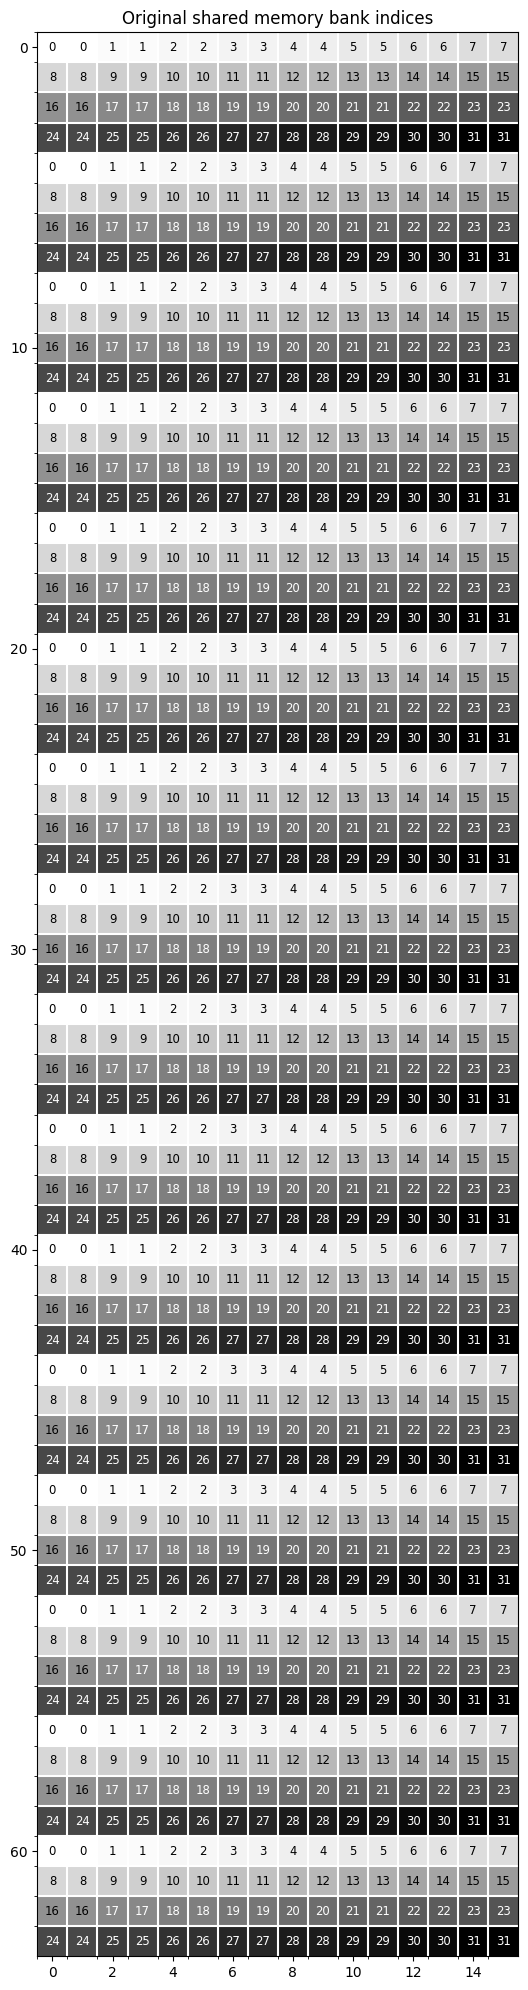

In [23]:
# Initialize parameters.
M = 64
N = 16
element_size = 2

# Initialize the matrix with indices as its values.
matrix = np.arange(M * N).reshape((M, N))

# Divide the matrix into banks.
matrix_by_bank = ((matrix % (32 * 4 / element_size)) // (4 / element_size)).astype(int)

# Visualize the elements in As colored by banks.
plot_matrix(
    matrix_by_bank, matrix_by_bank, M, N, "Original shared memory bank indices", -1, save_file="kernel14_a_before")

In [ ]:
# Feel free to play around with the values below.
base     = 3 # 8 elements should always be packed together (or each row contains 8 elements) --> log2(8).
bits_num = 3 # 3 groups (64 / 8) to permute --> log2(8).
# Requirement: abs(shift) >= bits_num
shift    = 3 # each full-bank "row" contains 64 elements; log2(64) - base

# Create the swizzle_op object.
swizzle_op = Swizzle(bits_num, base, shift)
swizzled_matrix_by_banks, swizzled_matrix = perform_swizzle(swizzle_op, matrix)

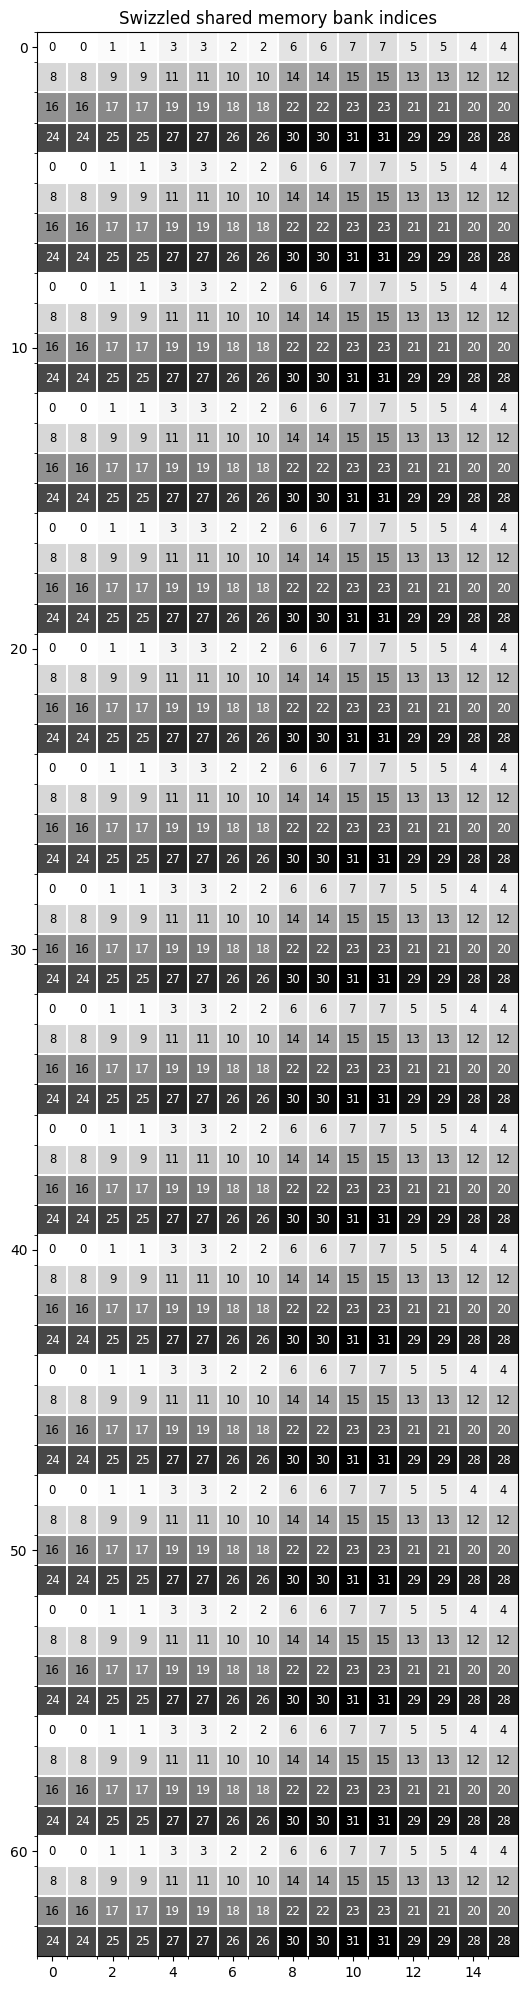

In [25]:
plot_matrix(
    swizzled_matrix_by_banks, swizzled_matrix_by_banks, M, N, "Swizzled shared memory bank indices", -1)

## B Fragment

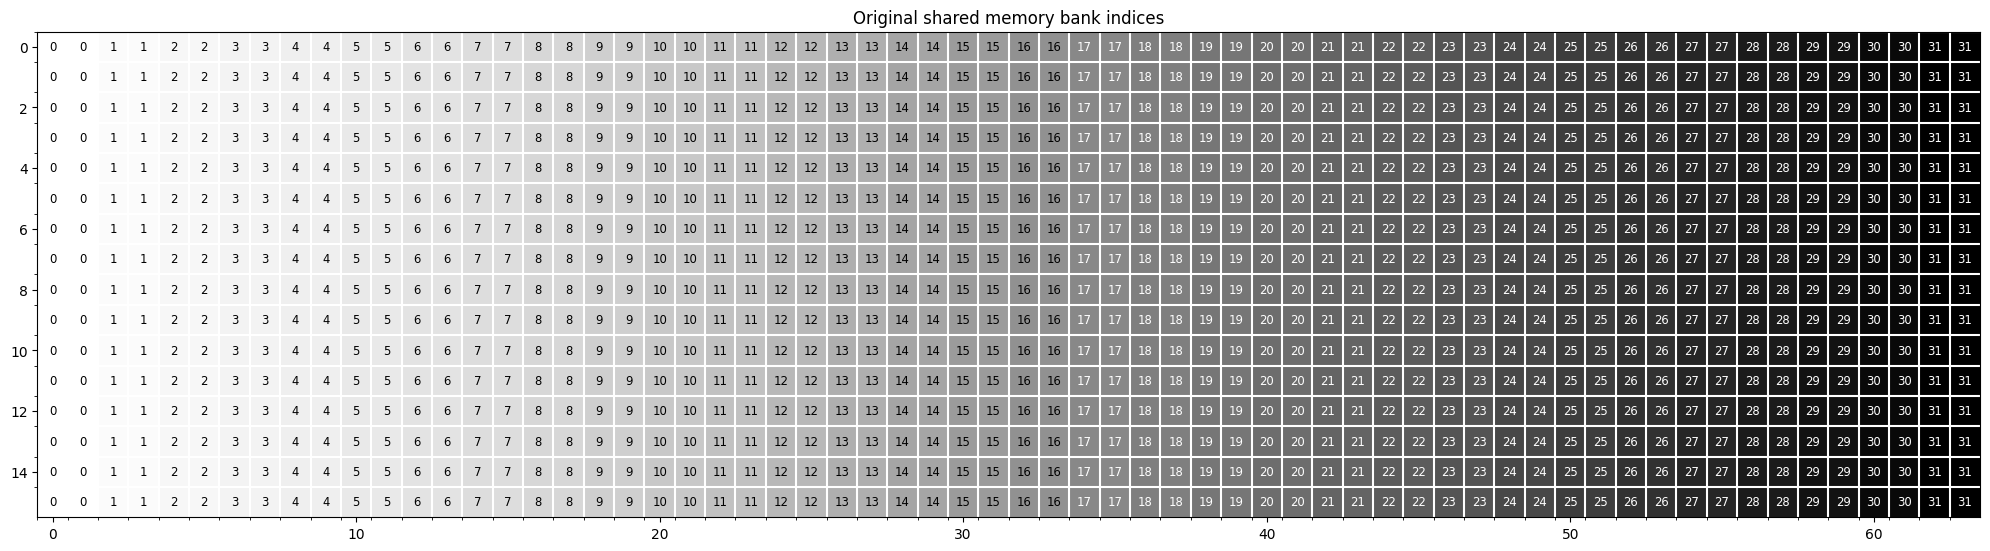

In [18]:
# Initialize parameters.
M = 16
N = 64
element_size = 2

# Initialize the matrix with indices as its values.
matrix = np.arange(M * N).reshape((M, N))

# Divide the matrix into banks.
matrix_by_bank = ((matrix % (32 * 4 / element_size)) // (4 / element_size)).astype(int)

# Visualize the elements in As colored by banks.
plot_matrix(
    matrix_by_bank, matrix_by_bank, M, N, "Original shared memory bank indices", -1, fig_size=(20, 10), save_file="kernel14_b_before")

In [19]:
# Feel free to play around with the values below.
base     = 3 # 8 elements should always be packed together (or each row contains 8 elements) --> log2(8).
bits_num = 3 # 3 groups (64 / 8) to permute --> log2(8).
# Requirement: abs(shift) >= bits_num
shift    = 3 # each full-bank "row" contains 64 elements; log2(64) - base

# Create the swizzle_op object.
swizzle_op = Swizzle(bits_num, base, shift)
swizzled_matrix_by_banks, swizzled_matrix = perform_swizzle(swizzle_op, matrix)

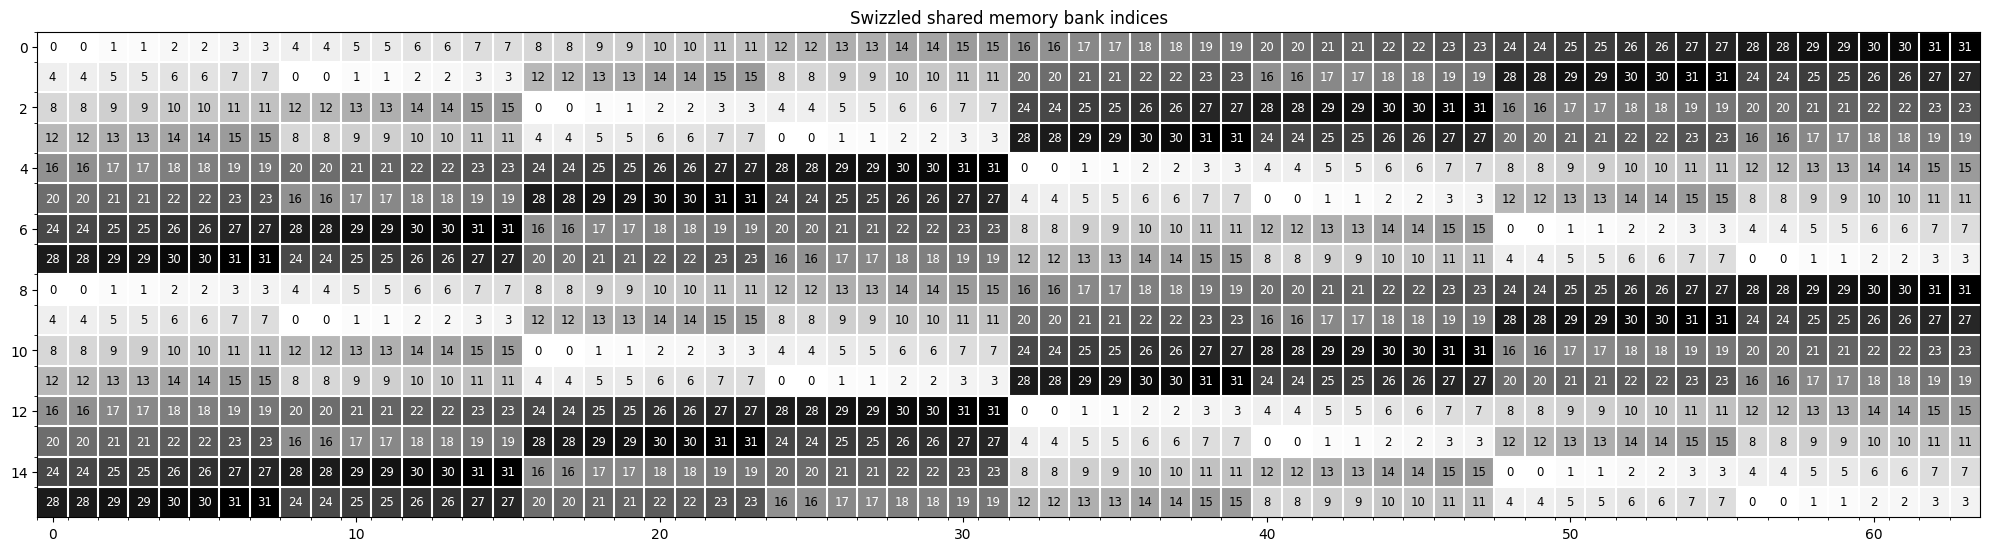

In [21]:
plot_matrix(
    swizzled_matrix_by_banks, swizzled_matrix_by_banks, M, N, "Swizzled shared memory bank indices", -1, fig_size=(20, 10), save_file="kernel14_b_after")